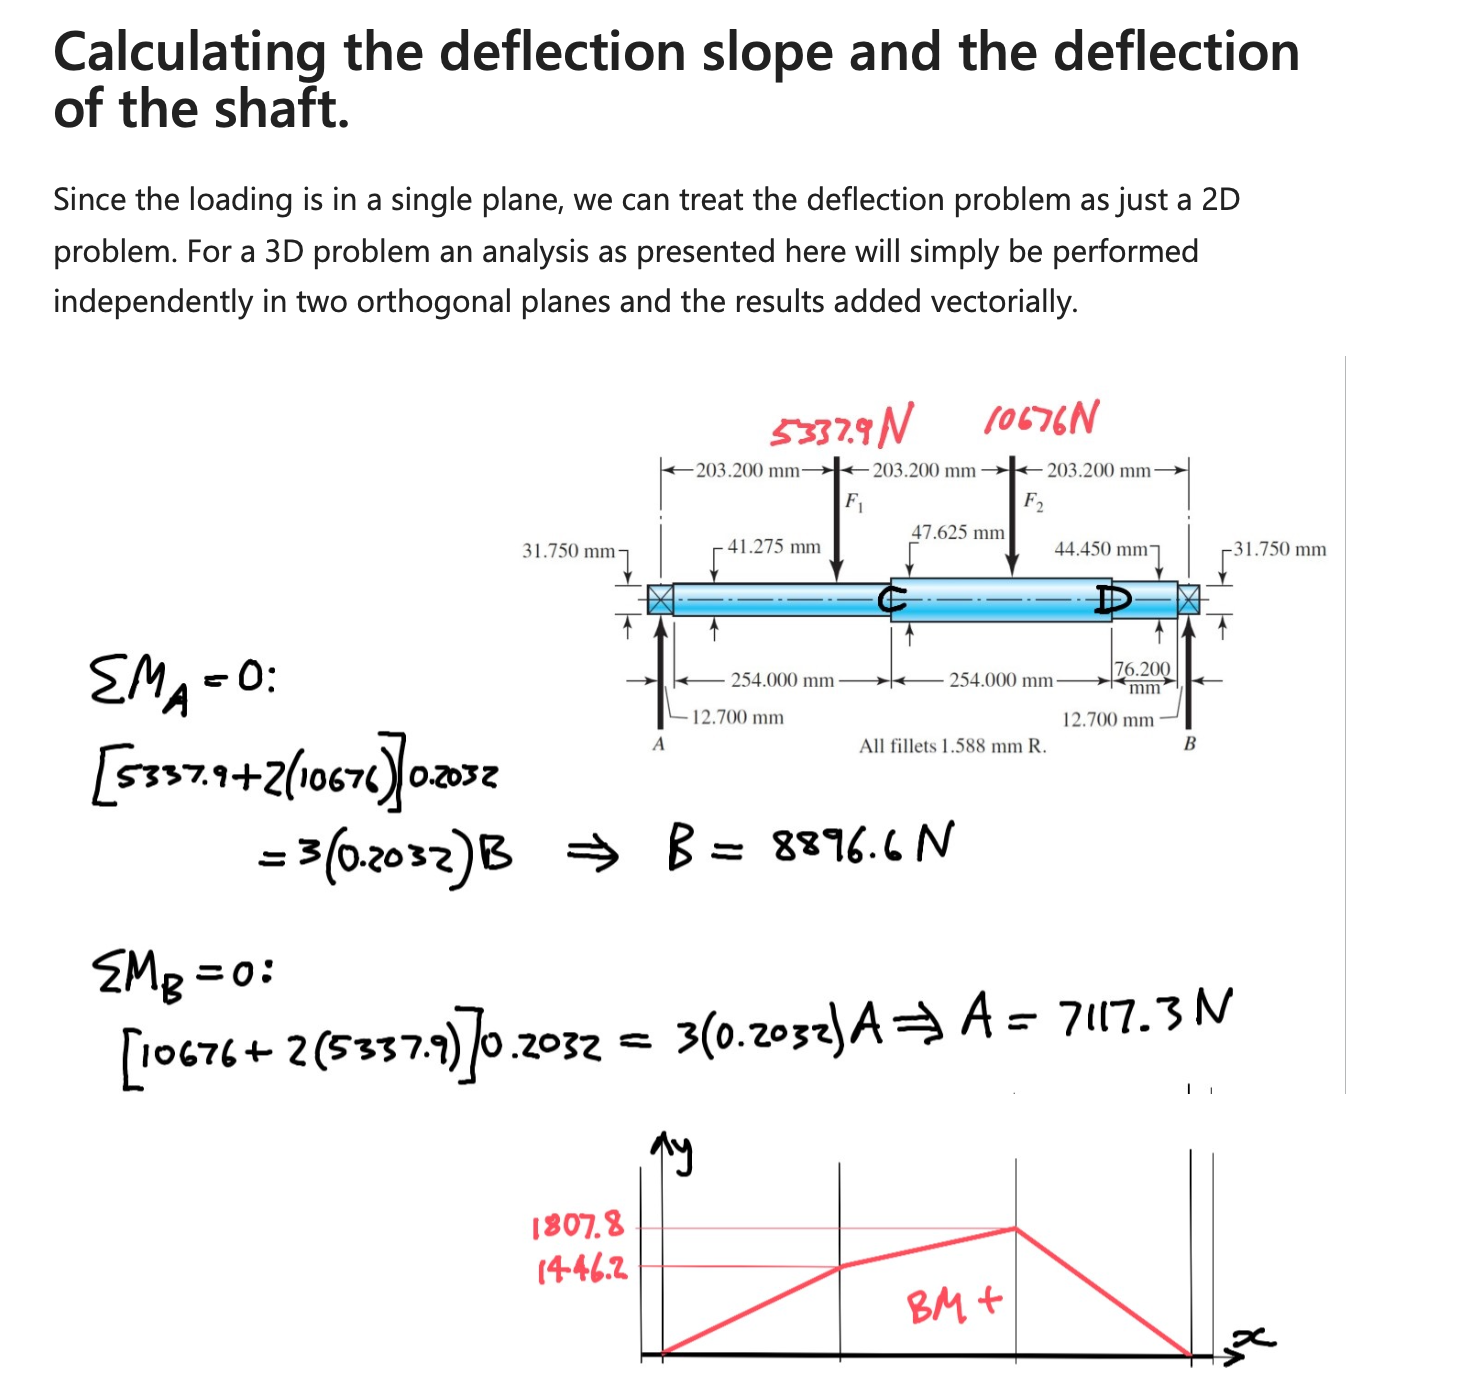

支反力: RA = -107.11 N, RB = 150.66 N


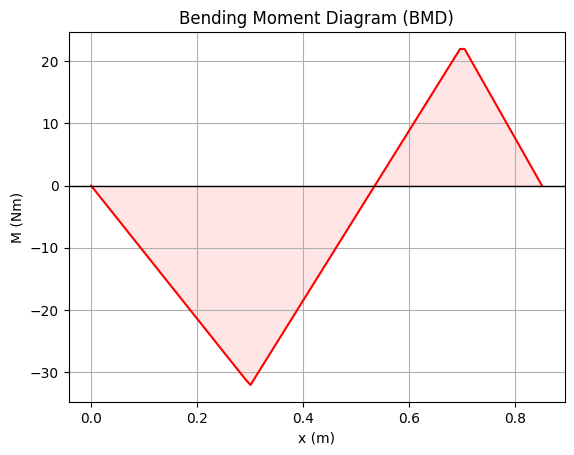

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, integrate, solve, pprint, pi

# ==========================================
# 步骤 1: 输入参数 (根据考试题目修改这里)
# ==========================================
bx = symbols('x', real=True)
E = 205e9  # 弹性模量 (Pa) [cite: 159]

# 载荷与位置 (单位: N, m)
F1, F2 = -243.95, 287.5  # 集中力 [cite: 89, 90]
L_total = 0.85          # 轴总长 [cite: 142]
pos_F1 = 0.3          # 力1位置
pos_C  = 0.3           # 轴肩C位置 (直径变化点) [cite: 140]
pos_F2 = 0.7           # 力2位置 [cite: 141]
pos_D  = 0.85          # 轴肩D位置 [cite: 142]

# 各段直径 (单位: m) -> 用于计算惯性矩 I = pi * d^4 / 64
d_small = 0.03 # 细段直径 [cite: 169]
d_large = 0.035 # 粗段直径 [cite: 194]
d_end   = 0.03  # 末端直径 [cite: 224]

# 计算各段的 I [cite: 170]
I1 = pi * d_small**4 / 64  # A 到 C 段
I3 = pi * d_large**4 / 64  # C 到 D 段
I5 = pi * d_end**4 / 64    # D 到 B 段

# ==========================================
# 步骤 2: 静力学平衡 (求支反力 RA, RB)
# ==========================================
# sum(MA) = 0 => RB * L = F1 * pos_F1 + F2 * pos_F2
RB_val = (F1 * pos_F1 + F2 * pos_F2) / L_total
RA_val = (F1 + F2) - RB_val
print(f"支反力: RA = {RA_val:.2f} N, RB = {RB_val:.2f} N")

# ==========================================
# 步骤 3: 分段建立弯矩方程 M(x) [cite: 115-131]
# ==========================================
# 第一段: A 到 F1 (0 < x < pos_F1)
M1 = RA_val * x
# 第二段: F1 到 F2 (pos_F1 < x < pos_F2)
M2 = RA_val * x - F1 * (x - pos_F1)
# 第三段: F2 到 B (pos_F2 < x < L_total)
M3 = RA_val * x - F1 * (x - pos_F1) - F2 * (x - pos_F2)

# ==========================================
# 步骤 4: 符号积分 (求斜率 θ 和挠度 v) [cite: 163]
# ==========================================
# 注意：由于 I 会变，我们积分 M(x) 得到 E*I*v' 和 E*I*v
C = symbols('C1:11') # 生成 C1 到 C10 的常数 [cite: 162]

# 这里简化为 3 个物理段（你可以根据需要增加到 5 个）
# 段 1 (A-F1)
EIv1_slope = integrate(M1, x) + C[0]
EIv1_disp  = integrate(EIv1_slope, x) + C[1]

# 段 2 (F1-C) -> 注意：F1到C直径没变，可以合在一段，但为了逻辑清晰可以分开
# 模板演示 5 段逻辑的精髓：连续性 [cite: 243-251]
# 为简单起见，考试时如果直径没变，可以少设几个常数

# ==========================================
# 步骤 5: 边界条件与连续性方程 [cite: 238-251]
# ==========================================
# 1. 支座处挠度为 0: v(0)=0, v(L)=0
# 2. 连接点处挠度相等: v_left = v_right
# 3. 连接点处转角相等: theta_left = theta_right
# 注意：因为 I 不同，theta = (EIv_slope) / (E * I)

# 例子：在轴肩 C 处的连续性
# eq = (EIv_slope_left / I_left) - (EIv_slope_right / I_right) 

# ==========================================
# 步骤 6: 绘图技巧 (BMD)
# ==========================================
def plot_bmd():
    x_vals = np.linspace(0, L_total, 100)
    m_vals = [float(M1.subs(x, xv)) if xv < pos_F1 else 
              float(M2.subs(x, xv)) if xv < pos_F2 else 
              float(M3.subs(x, xv)) for xv in x_vals]
    plt.plot(x_vals, m_vals, 'r', label='Bending Moment (Nm)')
    plt.fill_between(x_vals, m_vals, color='red', alpha=0.1)
    plt.axhline(0, color='black', lw=1)
    plt.title("Bending Moment Diagram (BMD)")
    plt.xlabel("x (m)")
    plt.ylabel("M (Nm)")
    plt.grid(True)
    plt.show()

plot_bmd() # 取消注释运行

图表已生成：shaft_analysis.png


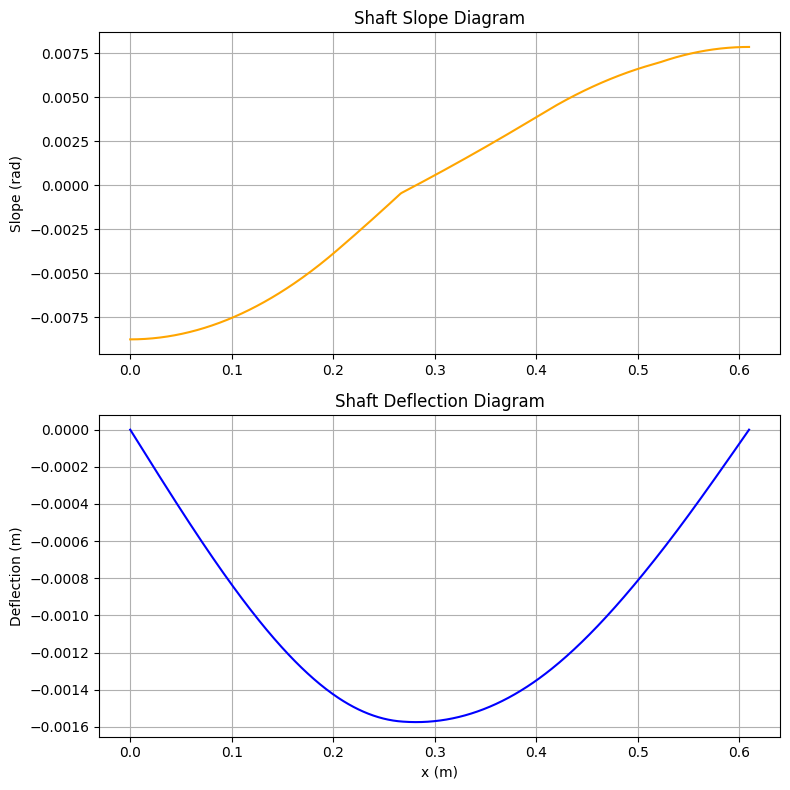

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, integrate, solve, pi, lambdify

# ==========================================
# 1. 基础参数输入 (根据你的设计修改)
# ==========================================
x = symbols('x', real=True)
E = 205e9  # 弹性模量 Pa [cite: 159]
L = 0.6096 # 轴总长 m [cite: 142]

# 关键位置点 (Boundary/Force locations)
pts = [0, 0.2032, 0.2667, 0.4064, 0.5207, 0.6096] # A, F1, C, F2, D, B [cite: 139-142]
# 各段对应的截面惯性矩 I (单位: m^4)
# 注意：如果直径 d 变了，I 必须重新计算 [cite: 170, 195, 225]
ds = [0.041275, 0.041275, 0.047625, 0.047625, 0.044450] # 5个区间的直径
Is = [pi*d**4/64 for d in ds]

# 2. 定义分段弯矩方程 M(x) 
# 这里以简支轴受两个集中力为例 (由支反力 RA=7117.3, F1=5337.9, F2=10676 计算得出)
RA = 7117.3
F1 = 5337.9
F2 = 10676
# [cite: 116, 123, 128]
M_exprs = [
    RA * x,                                      # Region 1
    RA * x - F1*(x - pts[1]),                    # Region 2
    RA * x - F1*(x - pts[1]),                    # Region 3 (直径变了但弯矩方程形式没变)
    RA * x - F1*(x - pts[1]) - F2*(x - pts[3]),  # Region 4
    RA * x - F1*(x - pts[1]) - F2*(x - pts[3])   # Region 5
]

# ==========================================
# 3. 积分与连续性方程构建 [cite: 163, 237]
# ==========================================
C = symbols('C1:11') # 生成 C1 到 C10
slopes = [] # 存储 theta(x) = (1/EI) * (integral(M) + C_odd)
disps = []  # 存储 v(x) = (1/EI) * (integral(theta*EI) + C_even)

for i in range(5):
    # 第一次积分得到 E*I*slope
    eq_slope = integrate(M_exprs[i], x) + C[2*i]
    slopes.append(eq_slope / (E * Is[i]))
    # 第二次积分得到 E*I*v
    eq_disp = integrate(eq_slope, x) + C[2*i+1]
    disps.append(eq_disp / (E * Is[i]))

# ==========================================
# 4. 边界条件与连续性求解 [cite: 239-251]
# ==========================================
conds = []
# 边界条件: 两端支撑点挠度为 0
conds.append(disps[0].subs(x, pts[0]))    # v(0) = 0
conds.append(disps[-1].subs(x, pts[-1]))  # v(L) = 0

# 连续性条件: 在每个连接点，左边的 slope/disp 等于右边
for i in range(4):
    mid_pt = pts[i+1]
    conds.append(slopes[i].subs(x, mid_pt) - slopes[i+1].subs(x, mid_pt))
    conds.append(disps[i].subs(x, mid_pt) - disps[i+1].subs(x, mid_pt))

# 解线性方程组得到常数 C
sol = solve(conds, C)

# ==========================================
# 5. 绘图部分 (Matplotlib 版) [cite: 389, 409]
# ==========================================
def plot_shaft_results():
    x_grid = np.linspace(0, L, 500)
    theta_vals = []
    v_vals = []

    # 将 sympy 表达式转化为可计算的函数
    final_slopes = [lambdify(x, s.subs(sol), 'numpy') for s in slopes]
    final_disps = [lambdify(x, d.subs(sol), 'numpy') for d in disps]

    for xv in x_grid:
        # 判断当前 x 属于哪个区间
        idx = next(i for i, p in enumerate(pts[1:]) if xv <= p)
        theta_vals.append(float(final_slopes[idx](xv)))
        v_vals.append(float(final_disps[idx](xv)))

    # 画图
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
    
    ax1.plot(x_grid, theta_vals, color='orange', label='Slope theta (rad)')
    ax1.set_title("Shaft Slope Diagram")
    ax1.set_ylabel("Slope (rad)")
    ax1.grid(True)

    ax2.plot(x_grid, v_vals, color='blue', label='Deflection v (m)')
    ax2.set_title("Shaft Deflection Diagram")
    ax2.set_ylabel("Deflection (m)")
    ax2.set_xlabel("x (m)")
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig('shaft_analysis.png')
    print("图表已生成：shaft_analysis.png")

plot_shaft_results()